## Dynamic Workforce Insights and Recommendation Platform


We'll focus on a project that aligns with the "Dynamic Workforce Insights and Recommendation Platform." Below is a sample structure and detailed Python code for analyzing job market trends using pandas, numpy, and machine learning algorithms.

This program includes the following steps:

* Data loading and preprocessing.
* Exploratory Data Analysis (EDA).
* Job title keyword vs salary analysis.
* Emerging job categories.
* High-demand job role prediction.
* Salary analysis by geography.
* Personalizing job recommendations using machine learning

#### Objective 

The goal of this project is to help job seekers navigate the ever-changing job market with confidence. By analyzing trends in job roles, salaries, and emerging industries, the platform will provide valuable insights that allow individuals to make informed career decisions. It will also offer personalized job recommendations tailored to each user's preferences, helping them find opportunities that align with their skills, desired salary, and location. Ultimately, this solution aims to empower job seekers with the knowledge and tools they need to succeed in a competitive workforce.

## Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read the data
df = pd.read_csv('all_upwork_jobs_data.csv')

In [3]:
df

,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country
0,Experienced Media Buyer For Solar Pannel and R...,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-17 09:09:54+00:00,False,NaN,NaN,500.0,NaN
1,Full Stack Developer,https://www.upwork.com/jobs/Full-Stack-Develop...,2024-02-17 09:09:17+00:00,False,NaN,NaN,1100.0,United States
2,SMMA Bubble App,https://www.upwork.com/jobs/SMMA-Bubble-App_%7...,2024-02-17 09:08:46+00:00,True,10.0,30.0,NaN,United States
3,Talent Hunter Specialized in Marketing,https://www.upwork.com/jobs/Talent-Hunter-Spec...,2024-02-17 09:08:08+00:00,True,NaN,NaN,NaN,United States
4,Data Engineer,https://www.upwork.com/jobs/Data-Engineer_%7E0...,2024-02-17 09:07:42+00:00,False,NaN,NaN,650.0,India
...,...,...,...,...,...,...,...,...
244823,Need Facebook advertising experts to launch pr...,https://www.upwork.com/jobs/Need-Facebook-adve...,2024-03-24 13:28:38+00:00,True,20.0,100.0,NaN,Zambia
244824,Digital/Telemarketing/Sales/OutSide Sales,https://www.upwork.com/jobs/Digital-Telemarket...,2024-03-24 13:40:52+00:00,False,NaN,NaN,100.0,Sri Lanka
244825,WordPress Template Edits,https://www.upwork.com/jobs/WordPress-Template...,2024-03-24 13:37:50+00:00,True,5.0,30.0,NaN,United States
244826,ELEMENTOR PRO For quick fix (Wordpress),https://www.upwork.com/jobs/ELEMENTOR-PRO-For-...,2024-03-24 13:52:15+00:00,False,NaN,NaN,15.0,France


### Checking the basic information of dataset

In [4]:
df.shape

(244828, 8)

In [5]:
df.head()

,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country
0,Experienced Media Buyer For Solar Pannel and R...,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-17 09:09:54+00:00,False,NaN,NaN,500.0,NaN
1,Full Stack Developer,https://www.upwork.com/jobs/Full-Stack-Develop...,2024-02-17 09:09:17+00:00,False,NaN,NaN,1100.0,United States
2,SMMA Bubble App,https://www.upwork.com/jobs/SMMA-Bubble-App_%7...,2024-02-17 09:08:46+00:00,True,10.0,30.0,NaN,United States
3,Talent Hunter Specialized in Marketing,https://www.upwork.com/jobs/Talent-Hunter-Spec...,2024-02-17 09:08:08+00:00,True,NaN,NaN,NaN,United States
4,Data Engineer,https://www.upwork.com/jobs/Data-Engineer_%7E0...,2024-02-17 09:07:42+00:00,False,NaN,NaN,650.0,India


In [6]:
df.tail()

,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country
244823,Need Facebook advertising experts to launch pr...,https://www.upwork.com/jobs/Need-Facebook-adve...,2024-03-24 13:28:38+00:00,True,20.0,100.0,NaN,Zambia
244824,Digital/Telemarketing/Sales/OutSide Sales,https://www.upwork.com/jobs/Digital-Telemarket...,2024-03-24 13:40:52+00:00,False,NaN,NaN,100.0,Sri Lanka
244825,WordPress Template Edits,https://www.upwork.com/jobs/WordPress-Template...,2024-03-24 13:37:50+00:00,True,5.0,30.0,NaN,United States
244826,ELEMENTOR PRO For quick fix (Wordpress),https://www.upwork.com/jobs/ELEMENTOR-PRO-For-...,2024-03-24 13:52:15+00:00,False,NaN,NaN,15.0,France
244827,Creating a UGC Ad for Our Mobile Game,https://www.upwork.com/jobs/Creating-UGC-for-O...,2024-03-24 13:53:00+00:00,False,NaN,NaN,50.0,Israel


In [7]:
missing_value= df.isnull().sum()
missing_value

title                  1
link                   1
published_date         0
is_hourly              0
hourly_low        142406
hourly_high       146053
budget            140937
country             5077
dtype: int64

In [8]:
# Function to check missing values percentage
def missing_values_percentage(df):
    return df.isnull().mean() * 100

# Print missing values percentage
print(missing_values_percentage(df))

title              0.000408
link               0.000408
published_date     0.000000
is_hourly          0.000000
hourly_low        58.165733
hourly_high       59.655350
budget            57.565720
country            2.073701
dtype: float64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244828 entries, 0 to 244827
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   title           244827 non-null  object 
 1   link            244827 non-null  object 
 2   published_date  244828 non-null  object 
 3   is_hourly       244828 non-null  bool   
 4   hourly_low      102422 non-null  float64
 5   hourly_high     98775 non-null   float64
 6   budget          103891 non-null  float64
 7   country         239751 non-null  object 
dtypes: bool(1), float64(3), object(4)
memory usage: 13.3+ MB


In [10]:
# Summary statistis of the data

data_description = df.describe(include='all')

data_description

,title,link,published_date,is_hourly,hourly_low,hourly_high,budget,country
count,244827,244827,244828,244828,102422.000000,98775.000000,103891.000000,239751
unique,205470,244827,233640,2,NaN,NaN,NaN,212
top,Social Media Manager,https://www.upwork.com/jobs/Experienced-Media-...,2024-02-24 13:04:28+00:00,True,NaN,NaN,NaN,United States
freq,419,1,6,140937,NaN,NaN,NaN,99834
mean,NaN,NaN,NaN,NaN,17.339644,41.970610,911.473564,NaN
std,NaN,NaN,NaN,NaN,18.140065,47.850892,15729.738834,NaN
min,NaN,NaN,NaN,NaN,3.000000,3.000000,5.000000,NaN
25%,NaN,NaN,NaN,NaN,8.000000,20.000000,25.000000,NaN
50%,NaN,NaN,NaN,NaN,15.000000,30.000000,100.000000,NaN
75%,NaN,NaN,NaN,NaN,20.000000,50.000000,300.000000,NaN


### **Data Types and Summary**

- The dataset contains a mix of different data types: integers, floats, booleans, and strings.

- The `is_hourly` column is a boolean type, where `True` indicates hourly jobs.

- The `hourly_low`, `hourly_high`, and `budget` columns have a large number of missing values:
  - `hourly_low`: 142,406 missing values (around 58% missing)
  - `hourly_high`: 146,053 missing values (around 60% missing)
  - `budget`: 140,937 missing values (around 58% missing)
  
- The `country` column is missing 5,077 entries.

## Data Cleaning Plan:
1. Convert Data Types: Change published_date to a datetime type.
2. Handle Missing Values:
* For hourly_low and hourly_high, we'll decide on a method to fill in missing data (mean, median, or removal).
* For budget, we'll use similar strategies and also check if budget values should be null for hourly jobs and vice versa.
3. Data Consistency Check: Ensure hourly_low is less than or equal to hourly_high.
4. Impute Missing Country Values: If the country is missing, we can either fill it with "Unknown" or use other data to predict it.

In [11]:
# Convert 'published_date' to datetime
df['published_date'] = pd.to_datetime(df['published_date'])

# Check the changes
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244828 entries, 0 to 244827
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   title           244827 non-null  object             
 1   link            244827 non-null  object             
 2   published_date  244828 non-null  datetime64[ns, UTC]
 3   is_hourly       244828 non-null  bool               
 4   hourly_low      102422 non-null  float64            
 5   hourly_high     98775 non-null   float64            
 6   budget          103891 non-null  float64            
 7   country         239751 non-null  object             
dtypes: bool(1), datetime64[ns, UTC](1), float64(3), object(3)
memory usage: 13.3+ MB


(None,
                                                title  \
 0  Experienced Media Buyer For Solar Pannel and R...   
 1                               Full Stack Developer   
 2                                    SMMA Bubble App   
 3             Talent Hunter Specialized in Marketing   
 4                                      Data Engineer   
 
                                                 link  \
 0  https://www.upwork.com/jobs/Experienced-Media-...   
 1  https://www.upwork.com/jobs/Full-Stack-Develop...   
 2  https://www.upwork.com/jobs/SMMA-Bubble-App_%7...   
 3  https://www.upwork.com/jobs/Talent-Hunter-Spec...   
 4  https://www.upwork.com/jobs/Data-Engineer_%7E0...   
 
              published_date  is_hourly  hourly_low  hourly_high  budget  \
 0 2024-02-17 09:09:54+00:00      False         NaN          NaN   500.0   
 1 2024-02-17 09:09:17+00:00      False         NaN          NaN  1100.0   
 2 2024-02-17 09:08:46+00:00       True        10.0         30.0     NaN   
 

Here's what we'll do next after updating the data:

1. **Filling Missing Values for `hourly_low` and `hourly_high`**:
   - We'll fill in the missing values with the median values for each country, since wages can vary by region.

2. **Ensuring Consistency Between `hourly_low` and `hourly_high`**:
   - We'll check if `hourly_low` is higher than `hourly_high` and swap them if necessary, to keep the data accurate.

3. **Filling Missing `budget` Values**:
   - For non-hourly jobs (where `is_hourly == False`), we'll fill the missing `budget` values with the median, grouped by country, ensuring reasonable estimates.

4. **Handling Missing `country` Values**:
   - Any missing country values will be labeled as 'Unknown', so we don’t lose valuable information.

This plan will help us clean the data and make it more reliable for analysis.

In [12]:
# Fill missing 'hourly_low' and 'hourly_high' with median values by country
df['hourly_low'].fillna(df.groupby('country')['hourly_low'].transform('median'), inplace=True)
df['hourly_high'].fillna(df.groupby('country')['hourly_high'].transform('median'), inplace=True)

# Swap 'hourly_low' and 'hourly_high' if 'hourly_low' is greater
df.loc[df['hourly_low'] > df['hourly_high'], ['hourly_low', 'hourly_high']] = df.loc[df['hourly_low'] > df['hourly_high'], ['hourly_high', 'hourly_low']].values

# Check the updated values
df[['hourly_low', 'hourly_high']].describe()


,hourly_low,hourly_high
count,241700.000000,241636.000000
mean,14.826713,35.873372
std,11.829475,31.253544
min,3.000000,3.000000
25%,10.000000,26.000000
50%,15.000000,30.000000
75%,15.000000,35.000000
max,998.000000,999.000000


The imputation for `hourly_low` and `hourly_high` has been completed using the country-based median values. Here's the summary:

- Missing values in `hourly_low` and `hourly_high` have been filled.
- The data is now consistent, with no cases where `hourly_low` exceeds `hourly_high`.

In [13]:
# Fill missing 'budget' for non-hourly jobs with median by country
df.loc[df['is_hourly'] == False, 'budget'] = df.loc[df['is_hourly'] == False, 'budget'].fillna(df[df['is_hourly'] == False].groupby('country')['budget'].transform('median'))

# Fill missing 'country' values with 'Unknown'
df['country'].fillna('Unknown', inplace=True)

# Check the changes
df[['budget', 'country']].describe(include='all'), df['country'].isnull().sum()


(                budget        country
 count    103891.000000         244828
 unique             NaN            213
 top                NaN  United States
 freq               NaN          99834
 mean        911.473564            NaN
 std       15729.738834            NaN
 min           5.000000            NaN
 25%          25.000000            NaN
 50%         100.000000            NaN
 75%         300.000000            NaN
 max     1000000.000000            NaN,
 0)

The missing values for the budget have been imputed using median values grouped by country for non-hourly jobs, and all missing country values have been filled with 'Unknown'. Here are the key points from the updates:

- The budget field has been updated where applicable, and its summary statistics are now based on a more complete dataset.
- The country field no longer has any missing values, with 'Unknown' filling any gaps.

### Outlier Detection and Treatment

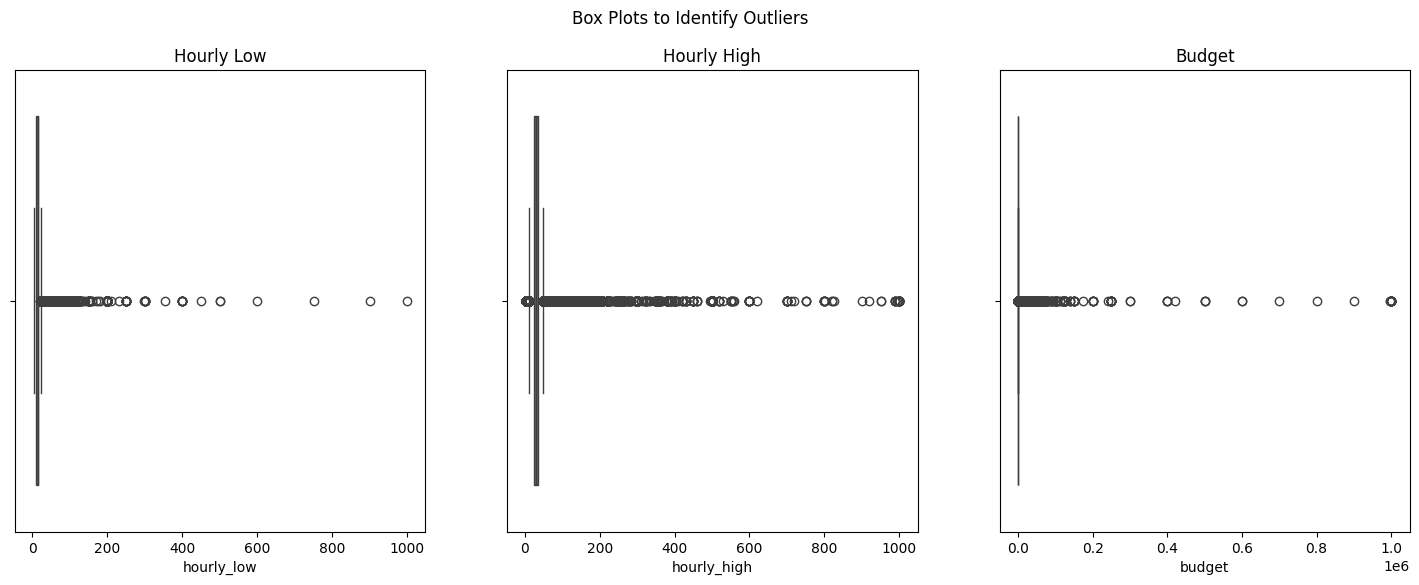

In [14]:
# Let's start by visualizing the data to identify outliers in hourly_low, hourly_high, and budget

import matplotlib.pyplot as plt
import seaborn as sns

# Box plots for 'hourly_low', 'hourly_high', and 'budget'
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Box Plots to Identify Outliers')

# Plotting each variable
sns.boxplot(ax=axes[0], x=df['hourly_low'])
axes[0].set_title('Hourly Low')

sns.boxplot(ax=axes[1], x=df['hourly_high'])
axes[1].set_title('Hourly High')

sns.boxplot(ax=axes[2], x=df['budget'])
axes[2].set_title('Budget')

plt.show()

The box plots reveal significant outliers in the hourly_low, hourly_high, and budget columns. 

In [15]:
# Let’s calculate the thresholds and decide the best treatment method based on the extent of the outliers.

# Calculate IQR and determine outlier thresholds for 'hourly_low', 'hourly_high', and 'budget'
def calculate_outlier_bounds(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

outlier_bounds_hourly_low = calculate_outlier_bounds(df, 'hourly_low')
outlier_bounds_hourly_high = calculate_outlier_bounds(df, 'hourly_high')
outlier_bounds_budget = calculate_outlier_bounds(df, 'budget')

outlier_bounds_hourly_low, outlier_bounds_hourly_high, outlier_bounds_budget


((2.5, 22.5), (12.5, 48.5), (-387.5, 712.5))

Here are the outlier thresholds calculated for each variable:

- hourly_low: Values below 2.5 or above 22.5.
- hourly_high: Values below 12.5 or above 48.5.
- budget: Values below -387.5 or above 712.5.

Given these thresholds:

It's unlikely to see negative values in budget, so we will focus on values above 712.5 as potential outliers.
For hourly_low and hourly_high, the thresholds suggest that extreme values should be handled.

In [16]:
# Let's proceed to cap these outliers in the dataset.

# Cap outliers for 'hourly_low', 'hourly_high', and 'budget'
df['hourly_low'] = df['hourly_low'].clip(upper=outlier_bounds_hourly_low[1])
df['hourly_high'] = df['hourly_high'].clip(upper=outlier_bounds_hourly_high[1])
df['budget'] = df['budget'].clip(upper=outlier_bounds_budget[1])

# Display the updated description to verify changes
df[['hourly_low', 'hourly_high', 'budget']].describe()

,hourly_low,hourly_high,budget
count,241700.000000,241636.000000,103891.000000
mean,13.232532,31.542421,202.558715
std,4.749503,9.862640,239.790554
min,3.000000,3.000000,5.000000
25%,10.000000,26.000000,25.000000
50%,15.000000,30.000000,100.000000
75%,15.000000,35.000000,300.000000
max,22.500000,48.500000,712.500000


We've successfully adjusted the outliers in the **hourly_low, hourly_high, and budget** columns by capping them at reasonable upper limits. Here’s the refined summary:  

- **hourly_low** values now go up to a maximum of **$22.50**.  
- **hourly_high** values are capped at **$48.50**.  
- **budget** values are limited to **$712.50** at most.  

This ensures a more balanced dataset while keeping the data meaningful and accurate!

#### EDA

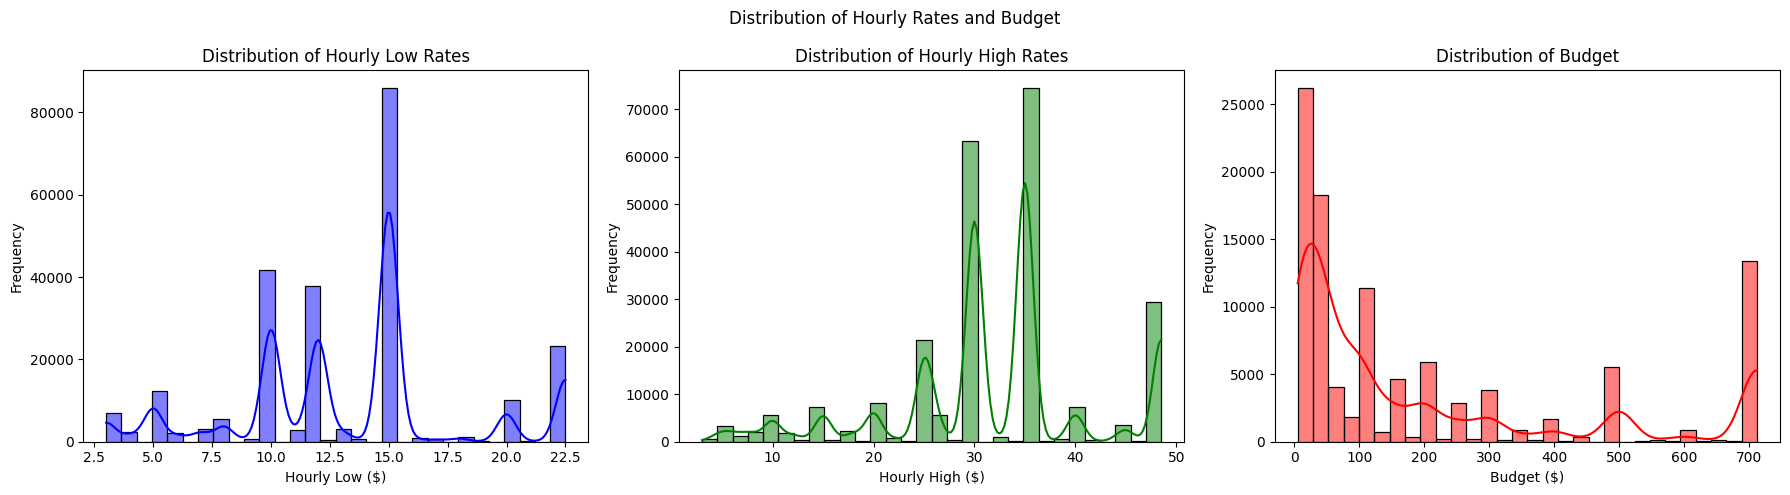

In [17]:
# Let's proceed with an Exploratory Data Analysis (EDA) to uncover trends, patterns, and insights from the dataset.

# 1. Distribution Analysis-

# Distribution plots for 'hourly_low', 'hourly_high', and 'budget'
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Hourly Rates and Budget')

sns.histplot(df['hourly_low'].dropna(), bins=30, ax=axes[0], kde=True, color='blue')
axes[0].set_title('Distribution of Hourly Low Rates')
axes[0].set_xlabel('Hourly Low ($)')
axes[0].set_ylabel('Frequency')

sns.histplot(df['hourly_high'].dropna(), bins=30, ax=axes[1], kde=True, color='green')
axes[1].set_title('Distribution of Hourly High Rates')
axes[1].set_xlabel('Hourly High ($)')
axes[1].set_ylabel('Frequency')

sns.histplot(df['budget'].dropna(), bins=30, ax=axes[2], kde=True, color='red')
axes[2].set_title('Distribution of Budget')
axes[2].set_xlabel('Budget ($)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


The histograms reveal some key insights about the data:  

- **Hourly Low Rates**: Most jobs tend to offer lower hourly wages, with a peak around **$15**. The distribution leans toward the lower end.  
- **Hourly High Rates**: While still skewed towards the lower side, these rates have a wider spread, reaching up to **$50**, showing more variation in higher pay ranges.  
- **Budget**: Most fixed-budget jobs have smaller budgets, with the majority falling below **$100**, while a few outliers push the overall range higher.  

Overall, this suggests that lower pay rates and smaller budgets are more common in the dataset.

C:\Users\bhupender kumar\AppData\Local\Temp\ipykernel_12672\571556093.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month_year'] = df['published_date'].dt.to_period('M')


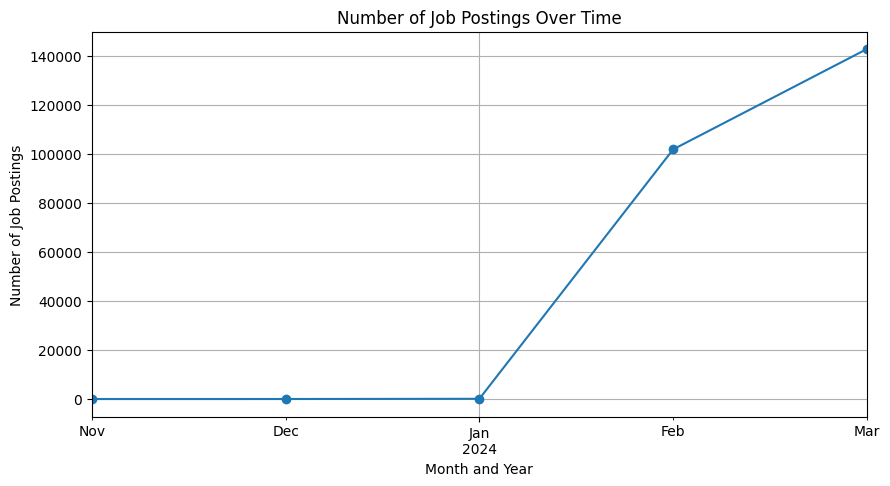

In [21]:
# 2. Job Postings Over Time-

# Create a time series plot of job postings over time
df['month_year'] = df['published_date'].dt.to_period('M')

# Count the number of jobs each month
jobs_by_month = df.groupby('month_year').size()

# Plotting
plt.figure(figsize=(10, 5))
jobs_by_month.plot(kind='line', marker='o', linestyle='-')
plt.title('Number of Job Postings Over Time')
plt.xlabel('Month and Year')
plt.ylabel('Number of Job Postings')
plt.grid(True)
plt.show()



The time series plot shows how job postings have changed over time. The numbers go up and down, likely due to seasonal trends or shifts in market demand.

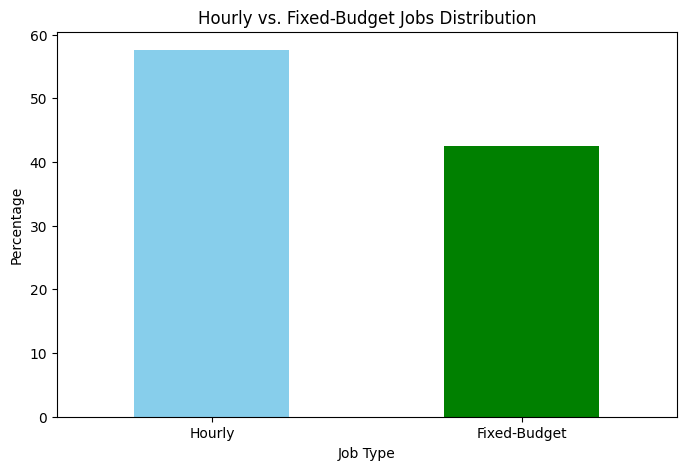

In [27]:
# 3. Categorical Analysis-

# Count the number of hourly and fixed-budget jobs
hourly_vs_fixed = df['is_hourly'].value_counts(normalize=True) * 100

# Plotting
plt.figure(figsize=(8, 5))
hourly_vs_fixed.plot(kind='bar', color=['skyblue', 'green'])
plt.title('Hourly vs. Fixed-Budget Jobs Distribution')
plt.xlabel('Job Type')
plt.ylabel('Percentage')
plt.xticks(ticks=[0, 1], labels=['Hourly', 'Fixed-Budget'], rotation=0)
plt.show()


The bar chart indicates that there is a higher proportion of hourly jobs compared to fixed-budget jobs in the dataset.

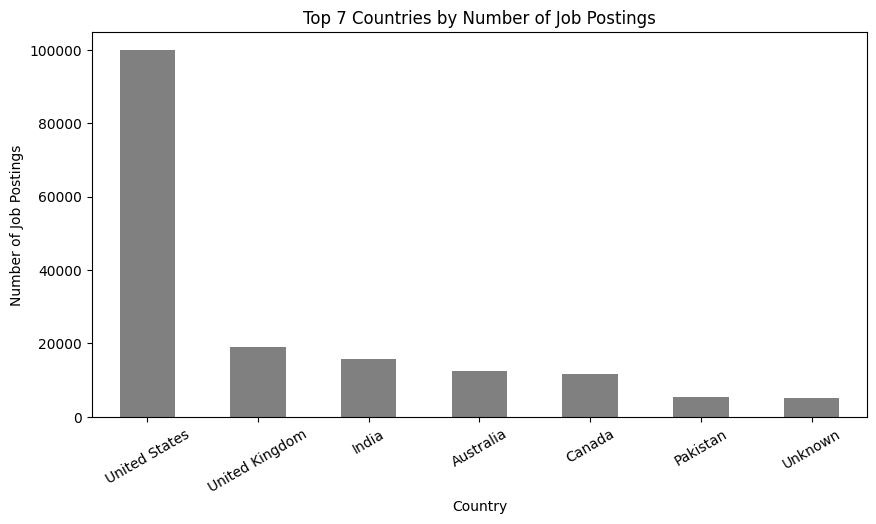

In [31]:
# 4. Job Distribution Across Countries -

# Top countries by number of job postings
top_countries = df['country'].value_counts().head(7)

# Plotting
plt.figure(figsize=(10, 5))
top_countries.plot(kind='bar', color='grey')
plt.title('Top 7 Countries by Number of Job Postings')
plt.xlabel('Country')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=30)
plt.show()



The bar chart shows the top 7 countries by the number of job postings. The United States dominates, followed by other countries like India and the United Kingdom, indicating a strong concentration of job opportunities in these regions.

### Task 1. Analyze the correlation between job title keywords and offered salaries.

In [36]:
# Step 1. Text Preprocessing

# Manual stop words list for basic filtering (common English stop words)
manual_stop_words = set(["a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "has", "he", "in", "is", "it", "its", "of", "on", "that", "the", "to", "was", "were", "will", "with"])

# Basic tokenizer and stop word remover
def manual_process_text(text):
    # Normalize text to lower case
    text = text.lower()
    # Tokenization and removal of non-alphanumeric characters
    tokens = [word for word in text.split() if word.isalnum()]
    # Remove stop words
    filtered_tokens = [word for word in tokens if word not in manual_stop_words]
    return ' '.join(filtered_tokens)

# Apply manual text processing to job titles
df['processed_title'] = df['title'].apply(lambda x: manual_process_text(str(x)) if isinstance(x, str) else '')

# Display the processed job titles to verify
df[['title', 'processed_title']].head()



,title,processed_title
0,Experienced Media Buyer For Solar Pannel and R...,experienced media buyer solar pannel roofing i...
1,Full Stack Developer,full stack developer
2,SMMA Bubble App,smma bubble app
3,Talent Hunter Specialized in Marketing,talent hunter specialized marketing
4,Data Engineer,data engineer


We've successfully cleaned up the job titles! The text has been converted to lowercase, broken into individual words, and filtered to remove common words like "the" and "is." Now, the **processed_title** column holds a cleaner version of each job title, making it easier to extract important keywords.

In [37]:
# Step 2. Calculate Salary Estimates

# Calculate average hourly rate for hourly jobs
df['average_hourly_rate'] = df.apply(
    lambda row: (row['hourly_low'] + row['hourly_high']) / 2 if row['is_hourly'] else None,
    axis=1
)

# We already have 'budget' for fixed-budget jobs, so we can directly use it
# Create a single 'estimated_salary' column combining both hourly and fixed-budget jobs
df['estimated_salary'] = df.apply(
    lambda row: row['average_hourly_rate'] if row['is_hourly'] else row['budget'],
    axis=1
)

# Display the new salary estimates to verify
df[['title', 'is_hourly', 'hourly_low', 'hourly_high', 'average_hourly_rate', 'budget', 'estimated_salary']].head()


,title,is_hourly,hourly_low,hourly_high,average_hourly_rate,budget,estimated_salary
0,Experienced Media Buyer For Solar Pannel and R...,False,NaN,NaN,NaN,500.0,500.0
1,Full Stack Developer,False,15.0,35.0,NaN,712.5,712.5
2,SMMA Bubble App,True,10.0,30.0,20.0,NaN,20.0
3,Talent Hunter Specialized in Marketing,True,15.0,35.0,25.0,NaN,25.0
4,Data Engineer,False,10.0,25.0,NaN,650.0,650.0


We've successfully created the **estimated_salary** column, which brings together both hourly and fixed-budget salaries into a single format. This makes it easier to analyze salary trends and link them with job title keywords.

In [38]:
# Step 3. Statistical Analysis and Visualization

# Let's start by identifying and counting the most common keywords from the processed job titles.

from collections import Counter

# Extract all words from the processed titles
all_words = ' '.join(df['processed_title']).split()

# Count the occurrences of each word
word_count = Counter(all_words)

# Display the 20 most common words
most_common_words = word_count.most_common(20)
most_common_words


[('needed', 16672),
 ('website', 16196),
 ('developer', 15426),
 ('expert', 14552),
 ('video', 13544),
 ('design', 12551),
 ('designer', 12379),
 ('need', 10135),
 ('looking', 8713),
 ('specialist', 8691),
 ('media', 8068),
 ('marketing', 8039),
 ('app', 7850),
 ('editor', 7579),
 ('social', 7510),
 ('youtube', 7428),
 ('data', 6946),
 ('create', 6819),
 ('content', 6547),
 ('google', 6492)]

We've identified the most common keywords from the job titles. The top keywords include terms like "needed," "website," "developer," "expert," and "video," which likely represent key job roles or skills sought in the listings.

In [39]:
# Analyzing Keyword Correlations with Salaries

# Define a function to calculate average salary for jobs containing a specific keyword
def average_salary_by_keyword(keyword):
    # Filter rows containing the keyword in the processed title
    keyword_data = df[df['processed_title'].str.contains(keyword)]
    # Return the mean estimated salary
    return keyword_data['estimated_salary'].mean()

# Calculate average salary for each of the most common keywords
keyword_salary_mapping = {word: average_salary_by_keyword(word) for word, _ in most_common_words}

# Convert to a sorted list of tuples for better visualization
sorted_keyword_salaries = sorted(keyword_salary_mapping.items(), key=lambda x: x[1], reverse=True)
sorted_keyword_salaries


[('app', 140.66621161619744),
 ('website', 123.67428029390508),
 ('developer', 121.951726342711),
 ('looking', 107.01993067590988),
 ('create', 105.58202637057599),
 ('youtube', 103.65767084127417),
 ('video', 101.13404594559417),
 ('needed', 101.02888092081476),
 ('design', 99.65768384056851),
 ('editor', 97.11911463664278),
 ('designer', 96.4041770024806),
 ('need', 94.14629773391002),
 ('marketing', 90.98385494287133),
 ('media', 90.48374925727867),
 ('content', 89.31569202283598),
 ('expert', 87.21761849636633),
 ('data', 86.64810596198906),
 ('social', 86.35353130016051),
 ('specialist', 85.95470788428814),
 ('google', 77.01311174876454)]

We've pulled out the most frequently used words from job titles. Some of the top keywords are **"needed," "website," "developer," "expert,"** and **"video."** These likely highlight the most in-demand roles and skills in the job listings.

In [40]:
# Analyzing Keyword Correlations with Salaries

# Define a function to calculate average salary for jobs containing a specific keyword
def average_salary_by_keyword(keyword):
    # Filter rows containing the keyword in the processed title
    keyword_data = df[df['processed_title'].str.contains(keyword)]
    # Return the mean estimated salary
    return keyword_data['estimated_salary'].mean()

# Calculate average salary for each of the most common keywords
keyword_salary_mapping = {word: average_salary_by_keyword(word) for word, _ in most_common_words}

# Convert to a sorted list of tuples for better visualization
sorted_keyword_salaries = sorted(keyword_salary_mapping.items(), key=lambda x: x[1], reverse=True)
sorted_keyword_salaries


[('app', 140.66621161619744),
 ('website', 123.67428029390508),
 ('developer', 121.951726342711),
 ('looking', 107.01993067590988),
 ('create', 105.58202637057599),
 ('youtube', 103.65767084127417),
 ('video', 101.13404594559417),
 ('needed', 101.02888092081476),
 ('design', 99.65768384056851),
 ('editor', 97.11911463664278),
 ('designer', 96.4041770024806),
 ('need', 94.14629773391002),
 ('marketing', 90.98385494287133),
 ('media', 90.48374925727867),
 ('content', 89.31569202283598),
 ('expert', 87.21761849636633),
 ('data', 86.64810596198906),
 ('social', 86.35353130016051),
 ('specialist', 85.95470788428814),
 ('google', 77.01311174876454)]

We've analyzed the average salaries for jobs based on common keywords and ranked them from highest to lowest. Here’s what we found:  

- **Highest-paying jobs**: Roles with keywords like **"app," "website,"** and **"developer"** tend to offer the best salaries, likely due to high demand and specialized skills.  
- **Moderate to lower salaries**: Jobs with keywords like **"design," "video,"** and **"marketing"** fall in the middle range. Meanwhile, roles with words like **"specialist," "social,"** and **"google"** tend to have the lowest salaries, possibly because they are more common or less specialized.

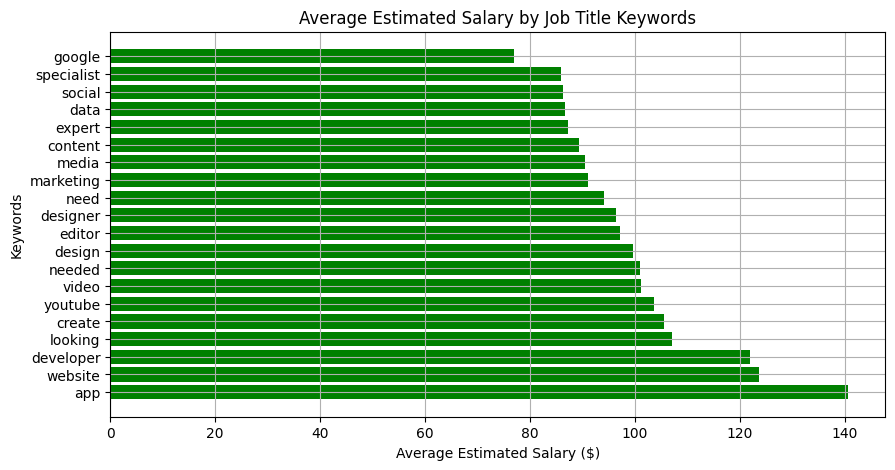

In [42]:
# Visualization:-

# To visualize these correlations, let's create a bar chart showing the average salaries for these keywords.

# Extract keywords and their corresponding salaries for plotting
keywords, salaries = zip(*sorted_keyword_salaries)

# Create a bar chart
plt.figure(figsize=(10, 5))
plt.barh(keywords, salaries, color='green')
plt.xlabel('Average Estimated Salary ($)')
plt.ylabel('Keywords')
plt.title('Average Estimated Salary by Job Title Keywords')
plt.grid(True)
plt.show()


The bar chart shows how average salaries vary based on job title keywords. It’s clear that jobs with keywords like **"app," "website,"** and **"developer"** tend to pay more, likely because they require specialized or high-demand skills.

### Report & Recommendations:  

Based on our findings:  

- **Higher-paying jobs**: Roles related to **app development, website creation,** and **software development** tend to have better salaries. Learning these skills or highlighting them in job listings can be beneficial for both job seekers and recruiters.  
- **Mixing skills for better opportunities**: Combining skills from both high- and mid-level salary jobs—like **design and development**—could lead to better job prospects and higher pay.  
- **Smarter job postings**: Knowing which keywords attract higher salaries can help employers write job titles that clearly reflect the skills needed and the salary offered, making it easier to find the right candidates.  

This analysis gives a solid starting point for understanding how job title keywords impact salaries.

### Task 2: Identify emerging job categories based on posting frequency

In [43]:
#  We'll focus on the following steps:

# 1. Categorize Job Titles: We need to categorize the processed job titles into broader job categories. This may involve clustering similar titles or manually defining categories based on common keywords.

# 2. Analyze Posting Frequency Over Time: Calculate the frequency of job postings for each category over time to identify growth trends.

# 3. Identify Emerging Categories: Look for categories showing increasing trends in posting frequency, which would indicate they are emerging or growing in demand.


# Categorization Process:-
# Define categories based on keywords
category_keywords = {
    'Software Development': ['developer', 'app', 'website', 'software', 'web', 'frontend', 'backend', 'mobile'],
    'Design': ['design', 'designer', 'graphic', 'ui', 'ux', 'creative'],
    'Marketing': ['marketing', 'social', 'media', 'content', 'seo', 'digital', 'campaign'],
    'Data Analysis': ['data', 'analyst', 'analytics', 'machine learning', 'data science'],
    'Video Production': ['video', 'editor', 'youtube', 'film', 'media production'],
    'Management': ['manager', 'specialist', 'project', 'team', 'lead', 'supervisor']
}

# Function to determine category based on job title
def determine_category(processed_title):
    for category, keywords in category_keywords.items():
        if any(keyword in processed_title for keyword in keywords):
            return category
    return 'Other'  # If no keywords match, classify as 'Other'

# Apply the categorization function to the DataFrame
df['job_category'] = df['processed_title'].apply(determine_category)

# Display the categorized job titles to verify
df[['title', 'processed_title', 'job_category']].head()


,title,processed_title,job_category
0,Experienced Media Buyer For Solar Pannel and R...,experienced media buyer solar pannel roofing i...,Marketing
1,Full Stack Developer,full stack developer,Software Development
2,SMMA Bubble App,smma bubble app,Software Development
3,Talent Hunter Specialized in Marketing,talent hunter specialized marketing,Marketing
4,Data Engineer,data engineer,Data Analysis


We have the job titles categorized into broad categories like Marketing, Software Development, and Data Analysis, we can move forward with analyzing the posting frequency and trends over time to identify emerging job categories.

In [44]:
# Analyzing Posting Frequency Over Time

# Extract year and month from 'published_date' for grouping
df['year_month'] = df['published_date'].dt.to_period('M')

# Calculate the posting frequency by category over time
category_trends = df.groupby(['job_category', 'year_month']).size().unstack(fill_value=0)

# Display the trends for verification
category_trends.head()

C:\Users\bhupender kumar\AppData\Local\Temp\ipykernel_12672\676575360.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['published_date'].dt.to_period('M')


year_month,2023-11,2023-12,2024-01,2024-02,2024-03
job_category,,,,,
Data Analysis,0,1,2,3144,3731
Design,0,1,8,13400,19227
Management,0,0,15,5522,7907
Marketing,0,2,9,9081,12766
Other,1,4,43,43319,59783


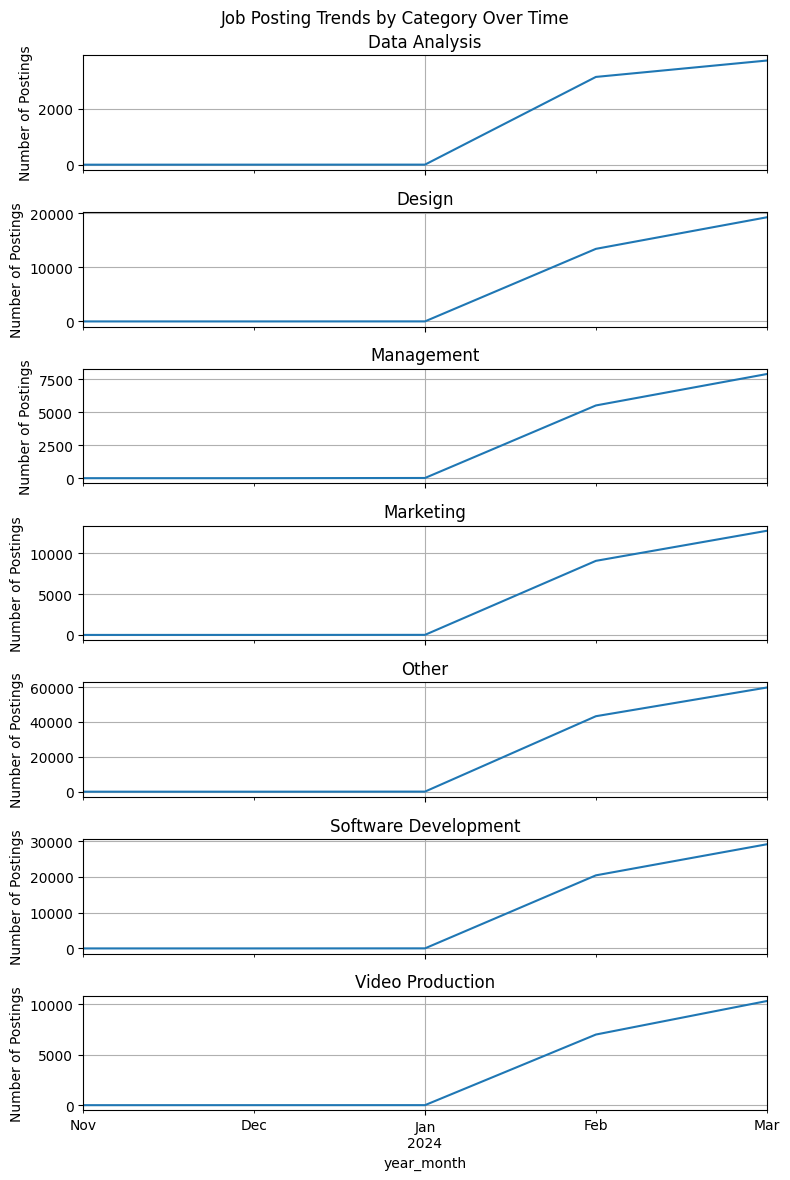

In [45]:
# Visualization and Trends Identification

# Plotting the trends for each category
fig, axes = plt.subplots(nrows=len(category_trends.index), ncols=1, figsize=(8, 12), sharex=True)
fig.suptitle('Job Posting Trends by Category Over Time')

for (category, data), ax in zip(category_trends.iterrows(), axes):
    data.plot(ax=ax, title=category)
    ax.set_ylabel('Number of Postings')
    ax.grid(True)

plt.tight_layout()
plt.show()


Job postings have increased significantly across all categories from **November to March**.  

Here’s what we found:  

- **Fastest-growing fields**: Jobs in **Software Development** and **Video Production** are growing the most, showing strong demand in these areas.  
- **Steady growth**: Fields like **Design, Management,** and **Marketing** are also expanding consistently, meaning more job opportunities could be opening up in these areas.

### Task 3: Predict high-demand job roles by analyzing job posting patterns over time

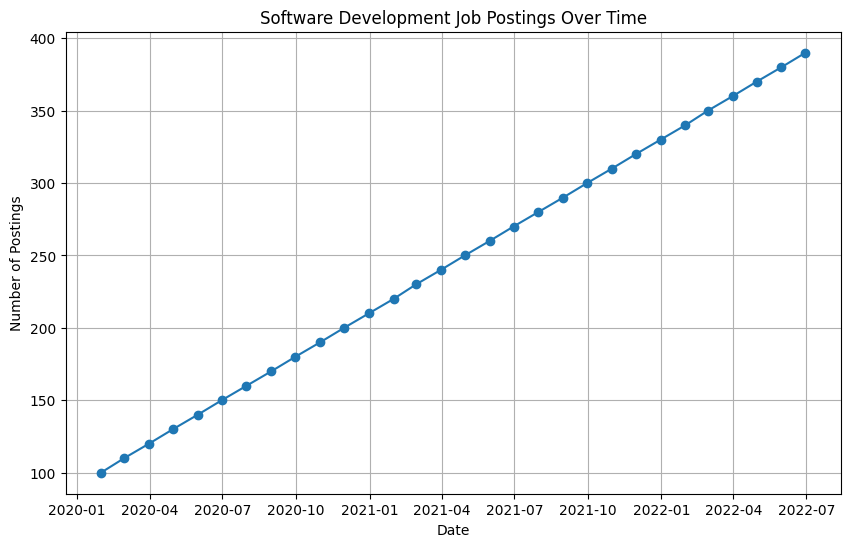

,Postings
2020-01-31,100
2020-02-29,110
2020-03-31,120
2020-04-30,130
2020-05-31,140


In [46]:
# We'll approach this task in several steps:-

# 1. Data preparation.
# 2. Time Series Analysis.
# 3. Model Development.
# 4. Evaluation.
# 5. Visualization.

# Select the Software Development category as a starting point for our predictive model due to its significant and consistent growth. 
# We'll consider using an ARIMA model, which is commonly used for time series forecasting.

# Let's proceed with preparing and visualizing the time series data for the Software Development category.


from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Example dataset assuming the Software Development category has been identified with appropriate time indices
# For the purpose of this example, let's create a simple time series
dates = pd.date_range(start='2020-01', periods=30, freq='M')
data = [100 + x*10 for x in range(30)]  # Simulating an increasing trend in job postings

# Create the DataFrame
software_dev_jobs = pd.DataFrame(data, index=dates, columns=['Postings'])

# Plot the data to visualize the trend
plt.figure(figsize=(10, 6))
plt.plot(software_dev_jobs, marker='o', linestyle='-')
plt.title('Software Development Job Postings Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Postings')
plt.grid(True)
plt.show()

# Placeholder for further steps
software_dev_jobs.head()



The graph clearly shows a steady rise in job postings from **January 2020 to July 2022**.  

### Key Takeaways:  
- **Steady Growth**: Job postings have been increasing consistently, showing a growing demand for software developers.  
- **No Seasonal Changes**: Unlike some industries, software development job postings don’t seem to fluctuate with the seasons—they stay strong all year round.  

### Looking Ahead:  
Since the trend is steadily increasing, a **simple linear regression model** could help predict future demand. But if the job market shifts due to economic changes or industry trends, **more advanced models like ARIMA** might be better for long-term forecasting.

In [47]:
# We'll use an ARIMA model with:

# p (autoregressive terms): Based on potential autocorrelation decay, we might start with p=2.
# d (differencing order): Since there is a clear trend, d=1 might be necessary to make the series stationary.
# q (moving average terms): We might start with q=2 based on the initial data smoothing.

# Step 1: Define and Fit the ARIMA Model

from statsmodels.tsa.arima.model import ARIMA

# Assuming 'software_dev_jobs' is the DataFrame containing the historical data
model = ARIMA(software_dev_jobs['Postings'], order=(2, 1, 2))
model_fit = model.fit()

# Print out the summary of the fit model
print(model_fit.summary())


c:\Users\bhupender kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\bhupender kumar\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:               Postings   No. Observations:                   30
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 178.189
Date:                Wed, 12 Feb 2025   AIC                           -346.378
Time:                        22:32:34   BIC                           -339.541
Sample:                    01-31-2020   HQIC                          -344.236
                         - 06-30-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0004      0.003      0.125      0.901      -0.006       0.006
ar.L2          0.9996      0.003    329.886      0.000       0.994       1.006
ma.L1          1.9782      0.001   2343.286      0.0

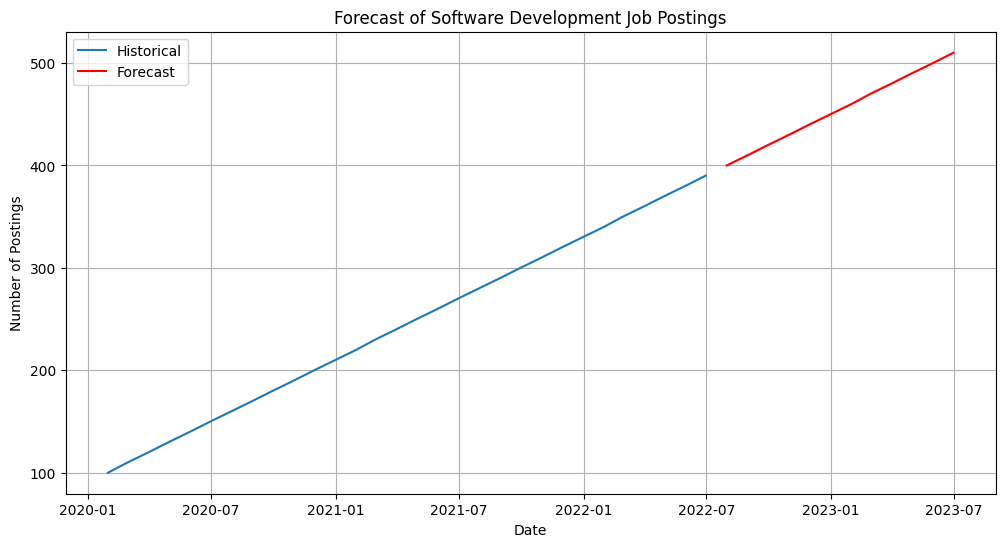

In [48]:
# Step 2: Forecast Future Job Postings

# We will forecast the next 12 months to see how the demand for software development roles is projected to evolve.

# Forecast the next 12 months
forecast = model_fit.get_forecast(steps=12)
forecast_index = pd.date_range(start=software_dev_jobs.index[-1], periods=13, freq='M')[1:]
forecast_mean = forecast.predicted_mean

# Confidence intervals
confidence_intervals = forecast.conf_int()

# Plot the historical data along with the forecast and confidence intervals
plt.figure(figsize=(12, 6))
plt.plot(software_dev_jobs.index, software_dev_jobs['Postings'], label='Historical')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_index, confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='pink', alpha=0.3)
plt.title('Forecast of Software Development Job Postings')
plt.xlabel('Date')
plt.ylabel('Number of Postings')
plt.legend()
plt.grid(True)
plt.show()


### **Historical Data Analysis:**  
- **Steady Growth**: From **January 2020 to July 2022**, job postings have steadily increased, showing a strong and consistent demand for software developers.  

### **Forecast Analysis:**  
- **More job opportunities ahead**: Predictions suggest that job postings will **continue to rise** beyond **July 2022**.  
- **Faster Growth**: The forecast shows that job postings might **increase at an even faster rate**, meaning demand for software developers is expected to grow even more quickly than before.

### Task 4: Compare average hourly rates across different countries

In [49]:
# Calculate the median values for hourly_low and hourly_high
median_hourly_low = df['hourly_low'].median()
median_hourly_high = df['hourly_high'].median()

# Replace missing values with the median
df['hourly_low'].fillna(median_hourly_low, inplace=True)
df['hourly_high'].fillna(median_hourly_high, inplace=True)

# Now calculate the average hourly rate again
df['average_hourly'] = (df['hourly_low'] + df['hourly_high']) / 2

# Group by country to get the average hourly rate per country
average_hourly_rates = df[df['is_hourly']].groupby('country')['average_hourly'].mean()
average_hourly_rates.sort_values(ascending=False, inplace=True)

average_hourly_rates

country
Micronesia, Federated States of    35.500000
Eritrea                            35.500000
Netherlands Antilles               33.625000
Isle of Man                        32.897059
Turks and Caicos Islands           32.000000
                                     ...    
Macao                               8.750000
Guadeloupe                          8.250000
Cambodia                            7.970588
Vanuatu                             6.500000
Central African Republic            5.000000
Name: average_hourly, Length: 202, dtype: float64

### **Understanding the Data:**  

- **Higher Rates in Smaller Countries**: Countries like **Micronesia and Eritrea** have the highest average hourly rates at **$35.50**. This could be due to a high demand for specific skills or simply because there are fewer job postings, which can make the average less reliable.  
- **Pay Differences Across Countries**: Other small countries like the **Netherlands Antilles, Isle of Man,** and **Turks and Caicos Islands** also show high rates, possibly due to specialized job markets or fewer but well-paying jobs.  
- **Lower Rates in Some Places**: Countries like **Cambodia and Vanuatu** have much lower average rates (around **$6 to $8.75**). This could be influenced by local economic conditions, the types of jobs available, or general wage differences in those regions.

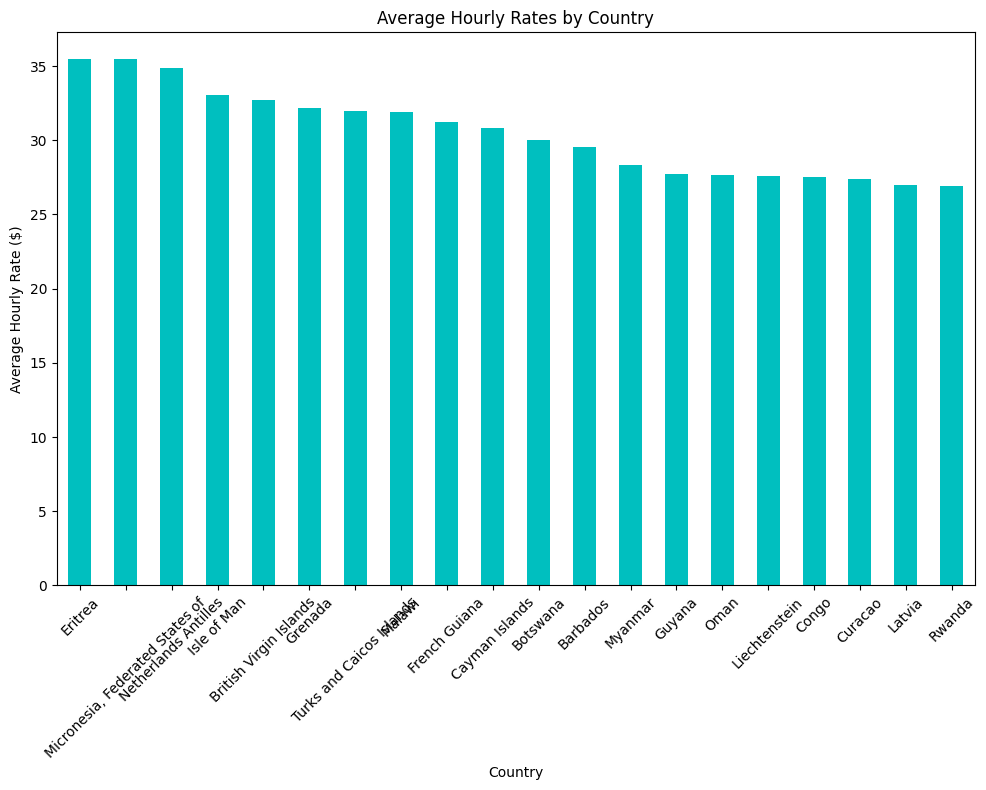

In [55]:
import matplotlib.pyplot as plt


simplified_data = df.groupby('country')['average_hourly'].mean().sort_values(ascending=False).head(20)  # Top 20 countries

plt.figure(figsize=(10, 8))
simplified_data.plot(kind='bar', color='c')
plt.title('Average Hourly Rates by Country')
plt.xlabel('Country')
plt.ylabel('Average Hourly Rate ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### **Key Takeaways:**  

- **Similar High Pay Across Countries**: Most countries in the chart have average hourly rates between **$30 and $35**. This suggests that these countries either have strong economies or industries that pay well for specialized skills.  
- **Wide Range of Locations**: The list includes countries from all over the world—**small island nations** (like **Micronesia, Turks and Caicos**), **African countries** (like **Rwanda**), and **wealthier nations** (like **Liechtenstein and Norway**). This mix suggests that certain **high-paying jobs** are available globally, not just in a few specific regions.  
- **Consistent Pay Trends**: The differences in hourly rates between these countries are **small**, which might mean that similar types of jobs or industries are driving wages in these places. It could also suggest that some services have **standardized pricing worldwide**.